In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better plot style
sns.set(style="whitegrid")

# Display all columns
pd.set_option('display.max_columns', None)

# LOAD DATASET

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 2. Load Excel dataset
file_path = "csew_dataset.xlsx"

xls = pd.ExcelFile(file_path)

print("Available sheets:")
print(xls.sheet_names)

Available sheets:
['Correction', 'Cover sheet', 'Table of contents', 'Notes', 'Table S1', 'Table S2', 'Table S3', 'Table S4', 'Table S5', 'Table S6', 'Table S7', 'Table S8', 'Table S9', 'Table S10', 'Table S11', 'Table S12', 'Table S13', 'Table S14 ', 'Table S15', 'Table S16', 'Table S17', 'Worksheet S18', 'Table S19', 'Table S20', 'Table S21', 'Table S22', 'Table S23', 'Table S24', 'Table S25', 'Table S26', 'Table S27', 'Table S28', 'Table S29', 'Table S30', 'Table S31', 'Table S32', 'Table S33', 'Table S34', 'Table S35', 'Table S36', 'Table S37', 'Table S38a', 'Table S38b', 'Table S39', 'Table S40', 'Table S41', 'Table S42', 'Table S43a', 'Table S43b', 'Table S43c', 'Table S44']


In [3]:
for sheet in xls.sheet_names:
    temp = pd.read_excel(file_path, sheet_name=sheet, header=None, nrows=1)
    print(sheet, ":", temp.iloc[0, 0])

Correction : A correction has been made to the Urban and Rural estimates and the unweighted bases in Table S26. This was due to a linking error.

We have corrected these errors. You can see all previous versions of this data on the previous versions page. 

We apologise for any inconvenience - first published 24th July 2024.
Cover sheet : Crime in England and Wales, Annual Supplementary tables - year ending March 2024
Table of contents : Table of contents
Notes : Notes
Table S1 : Table S1: Trends in ratings of the local police, people aged 16 and over, year ending March 2004 to year ending March 2024 [note 1][note 2][note 3]
Table S2 : Table S2: Ratings of the local police, people aged 16 and over, by personal characteristics, year ending March 2024 
Table S3 : Table S3: Ratings of the local police, people aged 16 and over, by household and area characteristics, year ending March 2024
Table S4 : Table S4: Trends in ratings and perceptions of the local police, people aged 16 years and o

# Load Table S27
# Table S27 contains: Percentage of people with high levels of worry about crime

In [4]:
file_path = "csew_dataset.xlsx"

xls = pd.ExcelFile(file_path)
print(xls.sheet_names)

['Correction', 'Cover sheet', 'Table of contents', 'Notes', 'Table S1', 'Table S2', 'Table S3', 'Table S4', 'Table S5', 'Table S6', 'Table S7', 'Table S8', 'Table S9', 'Table S10', 'Table S11', 'Table S12', 'Table S13', 'Table S14 ', 'Table S15', 'Table S16', 'Table S17', 'Worksheet S18', 'Table S19', 'Table S20', 'Table S21', 'Table S22', 'Table S23', 'Table S24', 'Table S25', 'Table S26', 'Table S27', 'Table S28', 'Table S29', 'Table S30', 'Table S31', 'Table S32', 'Table S33', 'Table S34', 'Table S35', 'Table S36', 'Table S37', 'Table S38a', 'Table S38b', 'Table S39', 'Table S40', 'Table S41', 'Table S42', 'Table S43a', 'Table S43b', 'Table S43c', 'Table S44']


In [5]:
raw_s27 = pd.read_excel(
    file_path,
    sheet_name="Table S27",
    header=None
)

raw_s27.head(15)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
0,Table S27: Percentage of people with high leve...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,England and Wales,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,This worksheet contains one table. Some cells ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Link to Notes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Some shorthand is used in this table, [x] deno...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Link to Table of contents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Source: Crime Survey for England and Wales fro...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Crime type,Jan 1992 to Dec 1992,Jan 1994 to Dec 1994,Jan 1996 to Dec 1996,Jan 1998 to Dec 1998,Jan 2000 to Dec 2000,Apr 2001 to Mar 2002,Apr 2002 to Mar 2003,Apr 2003 to Mar 2004,Apr 2004 to Mar 2005,Apr 2005 to Mar 2006,Apr 2006 to Mar 2007,Apr 2007 to Mar 2008,Apr 2008 to Mar 2009 [note 4],Apr 2009 to Mar 2010,Apr 2010 to Mar 2011,Apr 2011 to Mar 2012,Apr 2012 to Mar 2013,Apr 2013 to Mar 2014,Apr 2014 to Mar 2015,Apr 2015 to Mar 2016,Apr 2016 to Mar 2017,Apr 2017 to Mar 2018,Apr 2018 to Mar 2019,Apr 2019 to Mar 2020,Apr 2022 to Mar 2023,Apr 2023 to Mar 2024,Apr 2023 to Mar 2024 compared with Apr 2013 to...,Apr 2023 to Mar 2024 compared with Apr 2022 to...
8,Burglary,19,26,22.125462,19.3,19.2,15.2,14.8,12.6,12.1,12.7,12.639486,11.546422,11.212001,10.177656,10.359202,11.447059,11.915373,11.071148,9.705866,10.666254,10.210727,10.059964,9.835853,9.922278,7.789778,7.364805,[s],[ns]
9,Car crime,[x],[x],[x],22.3,21,17.3,16.6,14.9,13.4,13.7,13.010669,11.939734,11.407549,10.122714,9.837738,9.944148,6.789854,6.81067,6.873378,6.042806,7.037161,6.670565,6.663276,6.818675,5.417961,6.255134,[ns],[ns]


In [6]:


# Check shape first
print("Shape:", raw_s27.shape)

# Display first rows
display(raw_s27.head())

Shape: (13, 29)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
0,Table S27: Percentage of people with high leve...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,England and Wales,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,This worksheet contains one table. Some cells ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Link to Notes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Some shorthand is used in this table, [x] deno...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Check available rows safely
rows_to_check = min(15, len(raw_s27))

for i in range(rows_to_check):
    row_values = raw_s27.iloc[i].astype(str).tolist()
    print(f"\nRow {i}")
    print(row_values[:10])


Row 0
['Table S27: Percentage of people with high levels of worry about crime, people aged 16 and over, year ending December 1992 to year ending March 2024 [note 1, 2, 3]', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan']

Row 1
['England and Wales', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan']

Row 2
['This worksheet contains one table. Some cells refer to notes which can be found on the Notes worksheet. The units in this table are percentages.', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan']

Row 3
['Link to Notes', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan']

Row 4
['Some shorthand is used in this table, [x] denotes data are not available. [z] denotes not applicable. [s] denotes there is a statistically significant change at the 5% level. [ns] denotes a non significant statistical change at the 5% level.', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan']

Row 5
['Link to Table of contents ', 'nan', 'na

In [8]:

import pandas as pd

# Correct FULL file path
file_path = r"D:\zeno_talent\New folder\New folder\week2\ANA_1\csew_dataset.xlsx"

# Read sheet
table_s27 = pd.read_excel(
    file_path,
    sheet_name="Table S27",
    header=7
)

# Display data
print(table_s27.head())

                                          Crime type Jan 1992 to Dec 1992  \
0                                           Burglary                   19   
1                                          Car crime                  [x]   
2                                     Fraud [note 5]                  [x]   
3                                      Violent crime                  [x]   
4  Unweighted base - number of people aged 16 and...                10044   

  Jan 1994 to Dec 1994 Jan 1996 to Dec 1996 Jan 1998 to Dec 1998  \
0                   26            22.125462                 19.3   
1                  [x]                  [x]                 22.3   
2                  [x]                  [x]                  [x]   
3                  [x]                  [x]                 24.6   
4                14502                 7973                14925   

  Jan 2000 to Dec 2000 Apr 2001 to Mar 2002 Apr 2002 to Mar 2003  \
0                 19.2                 15.2                 

# EDA

In [9]:

print("Shape of Table S27:", table_s27.shape)

print("\nColumn names:")
print(table_s27.columns.tolist())

print("\nData types:")
print(table_s27.dtypes)

print("\nMissing values:")
print(table_s27.isnull().sum())

print("\nFirst rows:")
display(table_s27.head())

print("\nLast rows:")
display(table_s27.tail())

Shape of Table S27: (5, 29)

Column names:
['Crime type', 'Jan 1992 to Dec 1992', 'Jan 1994 to Dec 1994', 'Jan 1996 to Dec 1996', 'Jan 1998 to Dec 1998', 'Jan 2000 to Dec 2000', 'Apr 2001 to Mar 2002', 'Apr 2002 to Mar 2003', 'Apr 2003 to Mar 2004', 'Apr 2004 to Mar 2005', 'Apr 2005 to Mar 2006', 'Apr 2006 to Mar 2007', 'Apr 2007 to Mar 2008', 'Apr 2008 to Mar 2009 [note 4]', 'Apr 2009 to Mar 2010', 'Apr 2010 to Mar 2011', 'Apr 2011 to Mar 2012', 'Apr  2012 to Mar 2013', 'Apr 2013 to Mar 2014', 'Apr 2014 to Mar 2015', 'Apr 2015 to Mar 2016', 'Apr 2016 to Mar 2017', 'Apr 2017 to Mar 2018', 'Apr 2018 to Mar 2019', 'Apr 2019 to Mar 2020', 'Apr 2022 to Mar 2023 ', 'Apr 2023 to Mar 2024', 'Apr 2023 to Mar 2024 compared with Apr 2013 to Mar 2014\nStatistically significant difference', 'Apr 2023 to Mar 2024 compared with Apr 2022 to Mar 2023\nStatistically significant difference']

Data types:
Crime type                                                                                        ob

,Crime type,Jan 1992 to Dec 1992,Jan 1994 to Dec 1994,Jan 1996 to Dec 1996,Jan 1998 to Dec 1998,Jan 2000 to Dec 2000,Apr 2001 to Mar 2002,Apr 2002 to Mar 2003,Apr 2003 to Mar 2004,Apr 2004 to Mar 2005,Apr 2005 to Mar 2006,Apr 2006 to Mar 2007,Apr 2007 to Mar 2008,Apr 2008 to Mar 2009 [note 4],Apr 2009 to Mar 2010,Apr 2010 to Mar 2011,Apr 2011 to Mar 2012,Apr 2012 to Mar 2013,Apr 2013 to Mar 2014,Apr 2014 to Mar 2015,Apr 2015 to Mar 2016,Apr 2016 to Mar 2017,Apr 2017 to Mar 2018,Apr 2018 to Mar 2019,Apr 2019 to Mar 2020,Apr 2022 to Mar 2023,Apr 2023 to Mar 2024,Apr 2023 to Mar 2024 compared with Apr 2013 to Mar 2014\nStatistically significant difference,Apr 2023 to Mar 2024 compared with Apr 2022 to Mar 2023\nStatistically significant difference
0,Burglary,19,26,22.125462,19.3,19.2,15.2,14.8,12.6,12.1,12.7,12.639486,11.546422,11.212001,10.177656,10.359202,11.447059,11.915373,11.071148,9.705866,10.666254,10.210727,10.059964,9.835853,9.922278,7.789778,7.364805,[s],[ns]
1,Car crime,[x],[x],[x],22.3,21,17.3,16.6,14.9,13.4,13.7,13.010669,11.939734,11.407549,10.122714,9.837738,9.944148,6.789854,6.81067,6.873378,6.042806,7.037161,6.670565,6.663276,6.818675,5.417961,6.255134,[ns],[ns]
2,Fraud [note 5],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],19.443122,18.936057,15.815442,16.122118,[z],[ns]
3,Violent crime,[x],[x],[x],24.6,23.7,21.8,20.8,16.3,16.3,17.2,17.080922,14.928697,13.577427,12.889262,13.176234,13.754124,12.035731,12.093452,11.085468,11.526388,10.946605,11.857167,9.497211,8.466515,7.682225,7.562798,[s],[ns]
4,Unweighted base - number of people aged 16 and...,10044,14502,7973,14925,19388,32738,36427,37872,45095,47780,47122,46888,11510,11167,11627,11538,8792,8751,8207,8729,8722,8543,8623.000000,8569.000000,7894.000000,7752.000000,NaN,NaN



Last rows:


,Crime type,Jan 1992 to Dec 1992,Jan 1994 to Dec 1994,Jan 1996 to Dec 1996,Jan 1998 to Dec 1998,Jan 2000 to Dec 2000,Apr 2001 to Mar 2002,Apr 2002 to Mar 2003,Apr 2003 to Mar 2004,Apr 2004 to Mar 2005,Apr 2005 to Mar 2006,Apr 2006 to Mar 2007,Apr 2007 to Mar 2008,Apr 2008 to Mar 2009 [note 4],Apr 2009 to Mar 2010,Apr 2010 to Mar 2011,Apr 2011 to Mar 2012,Apr 2012 to Mar 2013,Apr 2013 to Mar 2014,Apr 2014 to Mar 2015,Apr 2015 to Mar 2016,Apr 2016 to Mar 2017,Apr 2017 to Mar 2018,Apr 2018 to Mar 2019,Apr 2019 to Mar 2020,Apr 2022 to Mar 2023,Apr 2023 to Mar 2024,Apr 2023 to Mar 2024 compared with Apr 2013 to Mar 2014\nStatistically significant difference,Apr 2023 to Mar 2024 compared with Apr 2022 to Mar 2023\nStatistically significant difference
0,Burglary,19,26,22.125462,19.3,19.2,15.2,14.8,12.6,12.1,12.7,12.639486,11.546422,11.212001,10.177656,10.359202,11.447059,11.915373,11.071148,9.705866,10.666254,10.210727,10.059964,9.835853,9.922278,7.789778,7.364805,[s],[ns]
1,Car crime,[x],[x],[x],22.3,21,17.3,16.6,14.9,13.4,13.7,13.010669,11.939734,11.407549,10.122714,9.837738,9.944148,6.789854,6.81067,6.873378,6.042806,7.037161,6.670565,6.663276,6.818675,5.417961,6.255134,[ns],[ns]
2,Fraud [note 5],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],19.443122,18.936057,15.815442,16.122118,[z],[ns]
3,Violent crime,[x],[x],[x],24.6,23.7,21.8,20.8,16.3,16.3,17.2,17.080922,14.928697,13.577427,12.889262,13.176234,13.754124,12.035731,12.093452,11.085468,11.526388,10.946605,11.857167,9.497211,8.466515,7.682225,7.562798,[s],[ns]
4,Unweighted base - number of people aged 16 and...,10044,14502,7973,14925,19388,32738,36427,37872,45095,47780,47122,46888,11510,11167,11627,11538,8792,8751,8207,8729,8722,8543,8623.000000,8569.000000,7894.000000,7752.000000,NaN,NaN


In [10]:
# Remove rows with missing values
table_s27 = table_s27.dropna()

In [11]:
print(table_s27.isnull().sum())

Crime type                                                                                       0
Jan 1992 to Dec 1992                                                                             0
Jan 1994 to Dec 1994                                                                             0
Jan 1996 to Dec 1996                                                                             0
Jan 1998 to Dec 1998                                                                             0
Jan 2000 to Dec 2000                                                                             0
Apr 2001 to Mar 2002                                                                             0
Apr 2002 to Mar 2003                                                                             0
Apr 2003 to Mar 2004                                                                             0
Apr 2004 to Mar 2005                                                                             0
Apr 2005 t

# Clean column names

In [12]:
table_s27.columns = (
    table_s27.columns
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

table_s27.head()

,Crime type,Jan 1992 to Dec 1992,Jan 1994 to Dec 1994,Jan 1996 to Dec 1996,Jan 1998 to Dec 1998,Jan 2000 to Dec 2000,Apr 2001 to Mar 2002,Apr 2002 to Mar 2003,Apr 2003 to Mar 2004,Apr 2004 to Mar 2005,Apr 2005 to Mar 2006,Apr 2006 to Mar 2007,Apr 2007 to Mar 2008,Apr 2008 to Mar 2009 [note 4],Apr 2009 to Mar 2010,Apr 2010 to Mar 2011,Apr 2011 to Mar 2012,Apr 2012 to Mar 2013,Apr 2013 to Mar 2014,Apr 2014 to Mar 2015,Apr 2015 to Mar 2016,Apr 2016 to Mar 2017,Apr 2017 to Mar 2018,Apr 2018 to Mar 2019,Apr 2019 to Mar 2020,Apr 2022 to Mar 2023,Apr 2023 to Mar 2024,Apr 2023 to Mar 2024 compared with Apr 2013 to Mar 2014 Statistically significant difference,Apr 2023 to Mar 2024 compared with Apr 2022 to Mar 2023 Statistically significant difference
0,Burglary,19,26,22.125462,19.3,19.2,15.2,14.8,12.6,12.1,12.7,12.639486,11.546422,11.212001,10.177656,10.359202,11.447059,11.915373,11.071148,9.705866,10.666254,10.210727,10.059964,9.835853,9.922278,7.789778,7.364805,[s],[ns]
1,Car crime,[x],[x],[x],22.3,21,17.3,16.6,14.9,13.4,13.7,13.010669,11.939734,11.407549,10.122714,9.837738,9.944148,6.789854,6.81067,6.873378,6.042806,7.037161,6.670565,6.663276,6.818675,5.417961,6.255134,[ns],[ns]
2,Fraud [note 5],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],19.443122,18.936057,15.815442,16.122118,[z],[ns]
3,Violent crime,[x],[x],[x],24.6,23.7,21.8,20.8,16.3,16.3,17.2,17.080922,14.928697,13.577427,12.889262,13.176234,13.754124,12.035731,12.093452,11.085468,11.526388,10.946605,11.857167,9.497211,8.466515,7.682225,7.562798,[s],[ns]


In [13]:
# Remove completely empty rows

table_s27 = table_s27.dropna(how="all")
table_s27 = table_s27.reset_index(drop=True)

table_s27.head()

,Crime type,Jan 1992 to Dec 1992,Jan 1994 to Dec 1994,Jan 1996 to Dec 1996,Jan 1998 to Dec 1998,Jan 2000 to Dec 2000,Apr 2001 to Mar 2002,Apr 2002 to Mar 2003,Apr 2003 to Mar 2004,Apr 2004 to Mar 2005,Apr 2005 to Mar 2006,Apr 2006 to Mar 2007,Apr 2007 to Mar 2008,Apr 2008 to Mar 2009 [note 4],Apr 2009 to Mar 2010,Apr 2010 to Mar 2011,Apr 2011 to Mar 2012,Apr 2012 to Mar 2013,Apr 2013 to Mar 2014,Apr 2014 to Mar 2015,Apr 2015 to Mar 2016,Apr 2016 to Mar 2017,Apr 2017 to Mar 2018,Apr 2018 to Mar 2019,Apr 2019 to Mar 2020,Apr 2022 to Mar 2023,Apr 2023 to Mar 2024,Apr 2023 to Mar 2024 compared with Apr 2013 to Mar 2014 Statistically significant difference,Apr 2023 to Mar 2024 compared with Apr 2022 to Mar 2023 Statistically significant difference
0,Burglary,19,26,22.125462,19.3,19.2,15.2,14.8,12.6,12.1,12.7,12.639486,11.546422,11.212001,10.177656,10.359202,11.447059,11.915373,11.071148,9.705866,10.666254,10.210727,10.059964,9.835853,9.922278,7.789778,7.364805,[s],[ns]
1,Car crime,[x],[x],[x],22.3,21,17.3,16.6,14.9,13.4,13.7,13.010669,11.939734,11.407549,10.122714,9.837738,9.944148,6.789854,6.81067,6.873378,6.042806,7.037161,6.670565,6.663276,6.818675,5.417961,6.255134,[ns],[ns]
2,Fraud [note 5],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],[x],19.443122,18.936057,15.815442,16.122118,[z],[ns]
3,Violent crime,[x],[x],[x],24.6,23.7,21.8,20.8,16.3,16.3,17.2,17.080922,14.928697,13.577427,12.889262,13.176234,13.754124,12.035731,12.093452,11.085468,11.526388,10.946605,11.857167,9.497211,8.466515,7.682225,7.562798,[s],[ns]


In [14]:
# Remove suppressed / invalid values

table_s27 = table_s27.replace({
    "[u]": np.nan,
    "[c]": np.nan,
    "[x]": np.nan,
    "[z]": np.nan,
    "..": np.nan,
    "": np.nan
})

table_s27.head()

C:\Users\rajmu\AppData\Local\Temp\ipykernel_20584\2653382474.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table_s27 = table_s27.replace({


,Crime type,Jan 1992 to Dec 1992,Jan 1994 to Dec 1994,Jan 1996 to Dec 1996,Jan 1998 to Dec 1998,Jan 2000 to Dec 2000,Apr 2001 to Mar 2002,Apr 2002 to Mar 2003,Apr 2003 to Mar 2004,Apr 2004 to Mar 2005,Apr 2005 to Mar 2006,Apr 2006 to Mar 2007,Apr 2007 to Mar 2008,Apr 2008 to Mar 2009 [note 4],Apr 2009 to Mar 2010,Apr 2010 to Mar 2011,Apr 2011 to Mar 2012,Apr 2012 to Mar 2013,Apr 2013 to Mar 2014,Apr 2014 to Mar 2015,Apr 2015 to Mar 2016,Apr 2016 to Mar 2017,Apr 2017 to Mar 2018,Apr 2018 to Mar 2019,Apr 2019 to Mar 2020,Apr 2022 to Mar 2023,Apr 2023 to Mar 2024,Apr 2023 to Mar 2024 compared with Apr 2013 to Mar 2014 Statistically significant difference,Apr 2023 to Mar 2024 compared with Apr 2022 to Mar 2023 Statistically significant difference
0,Burglary,19.0,26.0,22.125462,19.3,19.2,15.2,14.8,12.6,12.1,12.7,12.639486,11.546422,11.212001,10.177656,10.359202,11.447059,11.915373,11.071148,9.705866,10.666254,10.210727,10.059964,9.835853,9.922278,7.789778,7.364805,[s],[ns]
1,Car crime,NaN,NaN,NaN,22.3,21.0,17.3,16.6,14.9,13.4,13.7,13.010669,11.939734,11.407549,10.122714,9.837738,9.944148,6.789854,6.810670,6.873378,6.042806,7.037161,6.670565,6.663276,6.818675,5.417961,6.255134,[ns],[ns]
2,Fraud [note 5],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.443122,18.936057,15.815442,16.122118,NaN,[ns]
3,Violent crime,NaN,NaN,NaN,24.6,23.7,21.8,20.8,16.3,16.3,17.2,17.080922,14.928697,13.577427,12.889262,13.176234,13.754124,12.035731,12.093452,11.085468,11.526388,10.946605,11.857167,9.497211,8.466515,7.682225,7.562798,[s],[ns]


In [15]:
# Display clean columns again

print(table_s27.columns.tolist())
display(table_s27.head(10))

['Crime type', 'Jan 1992 to Dec 1992', 'Jan 1994 to Dec 1994', 'Jan 1996 to Dec 1996', 'Jan 1998 to Dec 1998', 'Jan 2000 to Dec 2000', 'Apr 2001 to Mar 2002', 'Apr 2002 to Mar 2003', 'Apr 2003 to Mar 2004', 'Apr 2004 to Mar 2005', 'Apr 2005 to Mar 2006', 'Apr 2006 to Mar 2007', 'Apr 2007 to Mar 2008', 'Apr 2008 to Mar 2009 [note 4]', 'Apr 2009 to Mar 2010', 'Apr 2010 to Mar 2011', 'Apr 2011 to Mar 2012', 'Apr  2012 to Mar 2013', 'Apr 2013 to Mar 2014', 'Apr 2014 to Mar 2015', 'Apr 2015 to Mar 2016', 'Apr 2016 to Mar 2017', 'Apr 2017 to Mar 2018', 'Apr 2018 to Mar 2019', 'Apr 2019 to Mar 2020', 'Apr 2022 to Mar 2023', 'Apr 2023 to Mar 2024', 'Apr 2023 to Mar 2024 compared with Apr 2013 to Mar 2014 Statistically significant difference', 'Apr 2023 to Mar 2024 compared with Apr 2022 to Mar 2023 Statistically significant difference']


,Crime type,Jan 1992 to Dec 1992,Jan 1994 to Dec 1994,Jan 1996 to Dec 1996,Jan 1998 to Dec 1998,Jan 2000 to Dec 2000,Apr 2001 to Mar 2002,Apr 2002 to Mar 2003,Apr 2003 to Mar 2004,Apr 2004 to Mar 2005,Apr 2005 to Mar 2006,Apr 2006 to Mar 2007,Apr 2007 to Mar 2008,Apr 2008 to Mar 2009 [note 4],Apr 2009 to Mar 2010,Apr 2010 to Mar 2011,Apr 2011 to Mar 2012,Apr 2012 to Mar 2013,Apr 2013 to Mar 2014,Apr 2014 to Mar 2015,Apr 2015 to Mar 2016,Apr 2016 to Mar 2017,Apr 2017 to Mar 2018,Apr 2018 to Mar 2019,Apr 2019 to Mar 2020,Apr 2022 to Mar 2023,Apr 2023 to Mar 2024,Apr 2023 to Mar 2024 compared with Apr 2013 to Mar 2014 Statistically significant difference,Apr 2023 to Mar 2024 compared with Apr 2022 to Mar 2023 Statistically significant difference
0,Burglary,19.0,26.0,22.125462,19.3,19.2,15.2,14.8,12.6,12.1,12.7,12.639486,11.546422,11.212001,10.177656,10.359202,11.447059,11.915373,11.071148,9.705866,10.666254,10.210727,10.059964,9.835853,9.922278,7.789778,7.364805,[s],[ns]
1,Car crime,NaN,NaN,NaN,22.3,21.0,17.3,16.6,14.9,13.4,13.7,13.010669,11.939734,11.407549,10.122714,9.837738,9.944148,6.789854,6.810670,6.873378,6.042806,7.037161,6.670565,6.663276,6.818675,5.417961,6.255134,[ns],[ns]
2,Fraud [note 5],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.443122,18.936057,15.815442,16.122118,NaN,[ns]
3,Violent crime,NaN,NaN,NaN,24.6,23.7,21.8,20.8,16.3,16.3,17.2,17.080922,14.928697,13.577427,12.889262,13.176234,13.754124,12.035731,12.093452,11.085468,11.526388,10.946605,11.857167,9.497211,8.466515,7.682225,7.562798,[s],[ns]


In [16]:
# 12. Convert wide table into long format

# First column contains indicator names
indicator_col = table_s27.columns[0]

trend_long = table_s27.melt(
    id_vars=indicator_col,
    var_name="Year",
    value_name="Percentage"
)

trend_long.head()

,Crime type,Year,Percentage
0,Burglary,Jan 1992 to Dec 1992,19.0
1,Car crime,Jan 1992 to Dec 1992,NaN
2,Fraud [note 5],Jan 1992 to Dec 1992,NaN
3,Violent crime,Jan 1992 to Dec 1992,NaN
4,Burglary,Jan 1994 to Dec 1994,26.0


In [17]:
# Clean percentage column

trend_long["Percentage"] = pd.to_numeric(
    trend_long["Percentage"],
    errors="coerce"
)

trend_long = trend_long.dropna(subset=["Percentage"])

trend_long.head()

,Crime type,Year,Percentage
0,Burglary,Jan 1992 to Dec 1992,19.000000
4,Burglary,Jan 1994 to Dec 1994,26.000000
8,Burglary,Jan 1996 to Dec 1996,22.125462
12,Burglary,Jan 1998 to Dec 1998,19.300000
13,Car crime,Jan 1998 to Dec 1998,22.300000


In [18]:
# Clean year column

def extract_end_year(year_text):
    year_text = str(year_text)
    match = re.search(r"20\d{2}|19\d{2}", year_text)
    if match:
        return int(match.group())
    return np.nan

trend_long["End_Year"] = trend_long["Year"].apply(extract_end_year)

trend_long = trend_long.dropna(subset=["End_Year"])
trend_long["End_Year"] = trend_long["End_Year"].astype(int)

trend_long.head()

,Crime type,Year,Percentage,End_Year
0,Burglary,Jan 1992 to Dec 1992,19.000000,1992
4,Burglary,Jan 1994 to Dec 1994,26.000000,1994
8,Burglary,Jan 1996 to Dec 1996,22.125462,1996
12,Burglary,Jan 1998 to Dec 1998,19.300000,1998
13,Car crime,Jan 1998 to Dec 1998,22.300000,1998


In [19]:
# Check available indicators

print("Available indicators in Table S27:")
print(trend_long[indicator_col].unique())

Available indicators in Table S27:
['Burglary' 'Car crime' 'Violent crime' 'Fraud [note 5]']


In [20]:
# 16. Select MH-related indicator
# Usually Table S27 contains worry about:
# - Burglary
# - Car crime
# - Violent crime

selected_indicator = trend_long[indicator_col].unique()[0]

mh_trend = trend_long[
    trend_long[indicator_col] == selected_indicator
].copy()

mh_trend = mh_trend.sort_values("End_Year")

display(mh_trend.head())
display(mh_trend.tail())

,Crime type,Year,Percentage,End_Year
0,Burglary,Jan 1992 to Dec 1992,19.000000,1992
4,Burglary,Jan 1994 to Dec 1994,26.000000,1994
8,Burglary,Jan 1996 to Dec 1996,22.125462,1996
12,Burglary,Jan 1998 to Dec 1998,19.300000,1998
16,Burglary,Jan 2000 to Dec 2000,19.200000,2000


,Crime type,Year,Percentage,End_Year
84,Burglary,Apr 2017 to Mar 2018,10.059964,2017
88,Burglary,Apr 2018 to Mar 2019,9.835853,2018
92,Burglary,Apr 2019 to Mar 2020,9.922278,2019
96,Burglary,Apr 2022 to Mar 2023,7.789778,2022
100,Burglary,Apr 2023 to Mar 2024,7.364805,2023


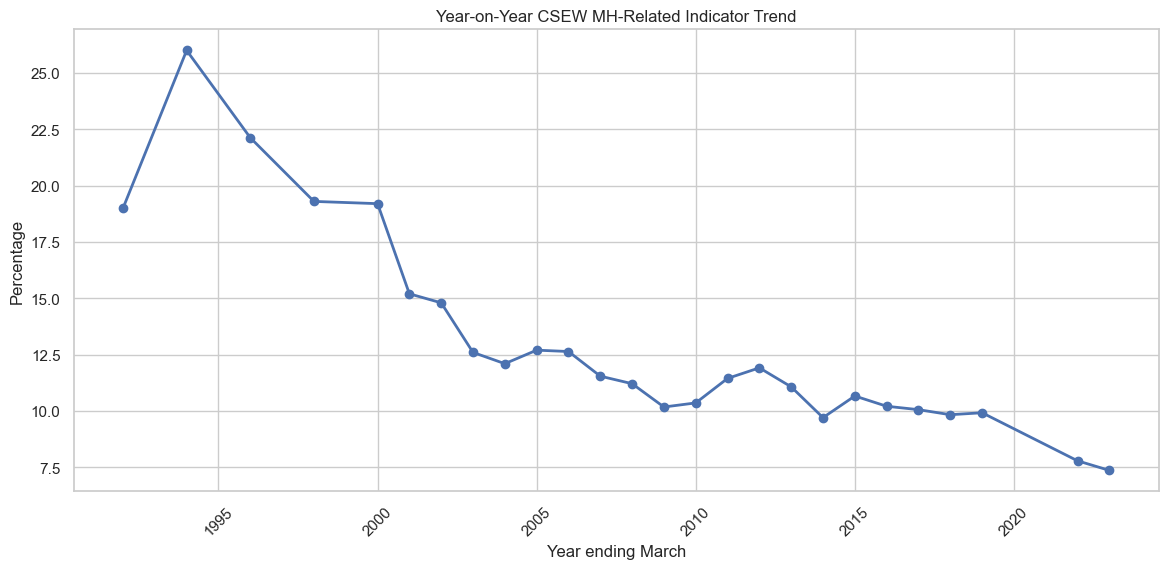

In [21]:
# 17. Plot year-on-year MH-related indicator trend

plt.figure(figsize=(14, 6))

plt.plot(
    mh_trend["End_Year"],
    mh_trend["Percentage"],
    marker="o",
    linewidth=2
)

plt.title("Year-on-Year CSEW MH-Related Indicator Trend")
plt.xlabel("Year ending March")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

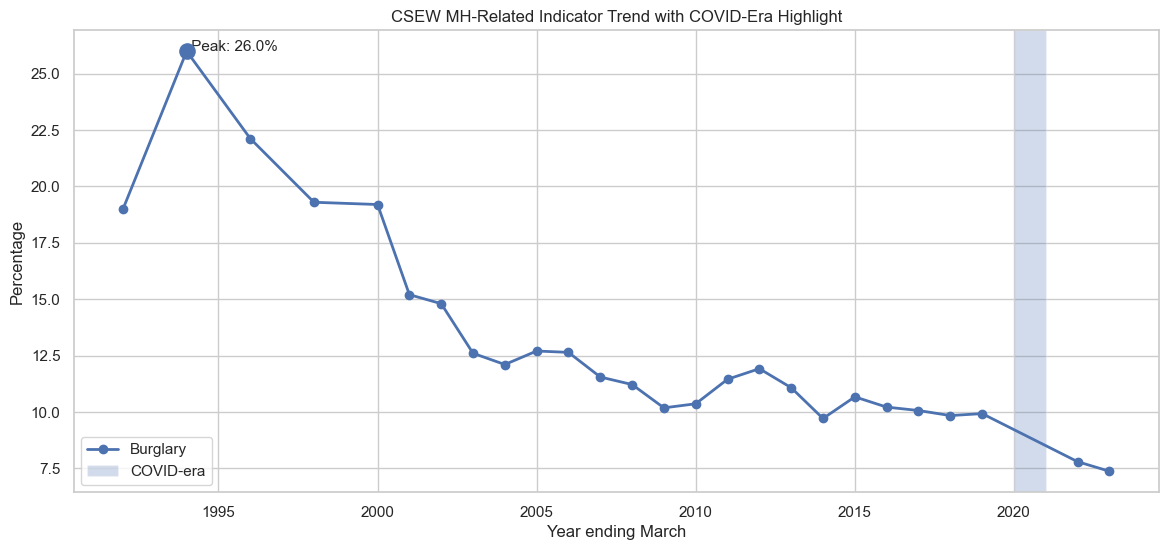

In [22]:
# Highlight COVID-era period

plt.figure(figsize=(14, 6))

plt.plot(
    mh_trend["End_Year"],
    mh_trend["Percentage"],
    marker="o",
    linewidth=2,
    label=selected_indicator
)

# Highlight COVID-era period
plt.axvspan(2020, 2021, alpha=0.25, label="COVID-era")

# Mark highest point
max_row = mh_trend.loc[mh_trend["Percentage"].idxmax()]

plt.scatter(
    max_row["End_Year"],
    max_row["Percentage"],
    s=120,
    zorder=5
)

plt.text(
    max_row["End_Year"],
    max_row["Percentage"],
    f" Peak: {max_row['Percentage']:.1f}%",
    fontsize=11
)

plt.title("CSEW MH-Related Indicator Trend with COVID-Era Highlight")
plt.xlabel("Year ending March")
plt.ylabel("Percentage")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Year-on-year percentage point change

mh_trend["YoY_Change"] = mh_trend["Percentage"].diff()

display(mh_trend)

,Crime type,Year,Percentage,End_Year,YoY_Change
0,Burglary,Jan 1992 to Dec 1992,19.000000,1992,NaN
4,Burglary,Jan 1994 to Dec 1994,26.000000,1994,7.000000
8,Burglary,Jan 1996 to Dec 1996,22.125462,1996,-3.874538
12,Burglary,Jan 1998 to Dec 1998,19.300000,1998,-2.825462
16,Burglary,Jan 2000 to Dec 2000,19.200000,2000,-0.100000
20,Burglary,Apr 2001 to Mar 2002,15.200000,2001,-4.000000
24,Burglary,Apr 2002 to Mar 2003,14.800000,2002,-0.400000
28,Burglary,Apr 2003 to Mar 2004,12.600000,2003,-2.200000
32,Burglary,Apr 2004 to Mar 2005,12.100000,2004,-0.500000
36,Burglary,Apr 2005 to Mar 2006,12.700000,2005,0.600000


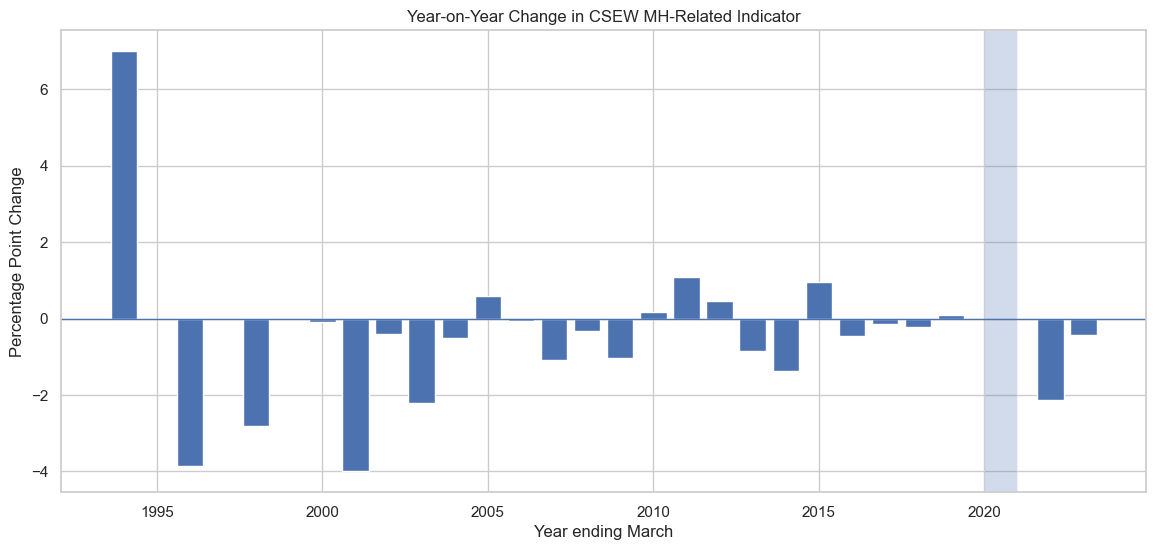

In [24]:
# Plot YoY change

plt.figure(figsize=(14, 6))

plt.bar(
    mh_trend["End_Year"],
    mh_trend["YoY_Change"]
)

plt.axhline(0, linewidth=1)

plt.axvspan(2020, 2021, alpha=0.25)

plt.title("Year-on-Year Change in CSEW MH-Related Indicator")
plt.xlabel("Year ending March")
plt.ylabel("Percentage Point Change")

plt.grid(True)
plt.show()

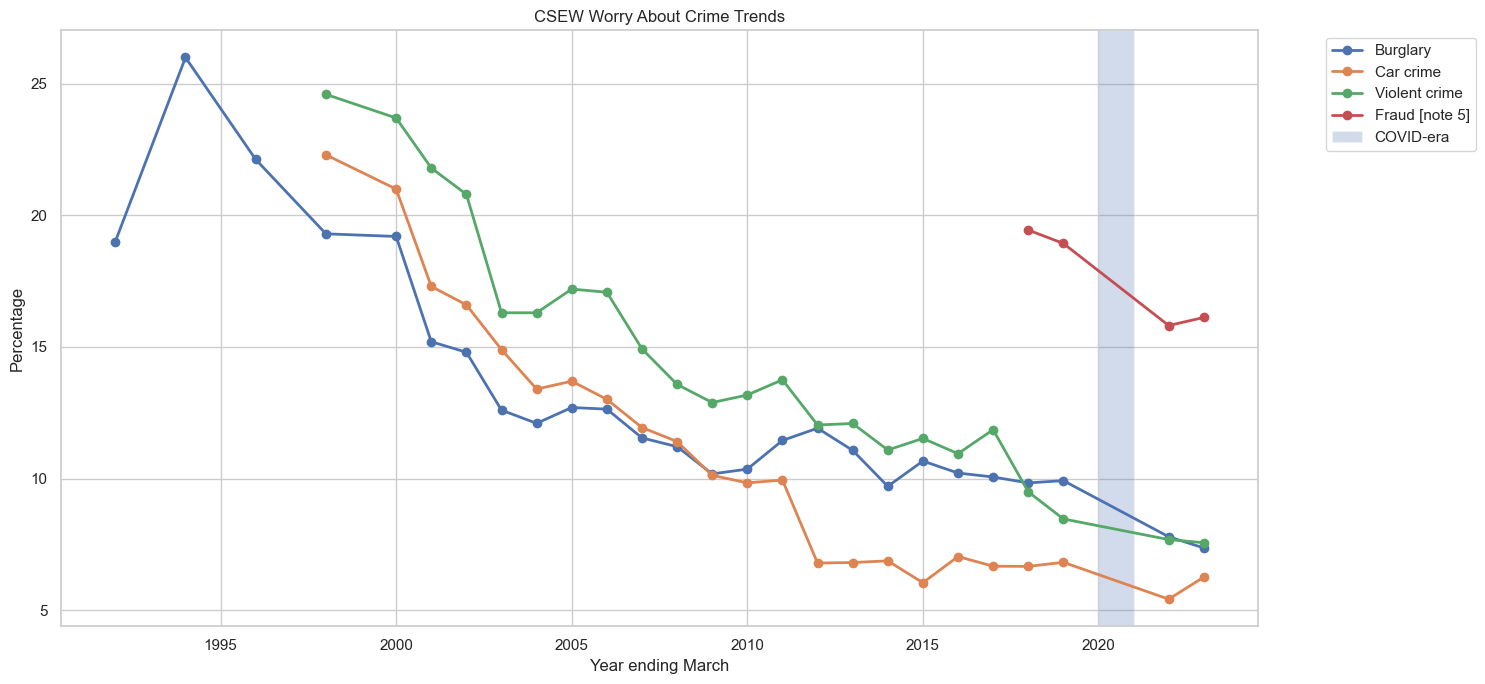

In [25]:
# Compare all worry indicators together

plt.figure(figsize=(15, 7))

for indicator in trend_long[indicator_col].unique():
    temp = trend_long[trend_long[indicator_col] == indicator].sort_values("End_Year")
    
    plt.plot(
        temp["End_Year"],
        temp["Percentage"],
        marker="o",
        linewidth=2,
        label=indicator
    )

plt.axvspan(2020, 2021, alpha=0.25, label="COVID-era")

plt.title("CSEW Worry About Crime Trends")
plt.xlabel("Year ending March")
plt.ylabel("Percentage")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# Descriptive statistics

summary_stats = trend_long.groupby(indicator_col)["Percentage"].describe()

display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
Crime type,,,,,,,,
Burglary,26.0,13.036513,4.535657,7.364805,10.185924,11.496740,14.275000,26.000000
Car crime,23.0,10.906175,4.937864,5.417961,6.800262,9.944148,13.550000,22.300000
Fraud [note 5],4.0,17.579185,1.875206,15.815442,16.045449,17.529088,19.062823,19.443122
Violent crime,23.0,14.298271,4.829256,7.562798,11.305928,13.176234,16.690461,24.600000


In [27]:
# Save cleaned trend data

trend_long.to_csv("cleaned_csew_mh_related_trends.csv", index=False)
mh_trend.to_csv("selected_mh_indicator_trend.csv", index=False)

print("CSV files saved successfully.")

CSV files saved successfully.


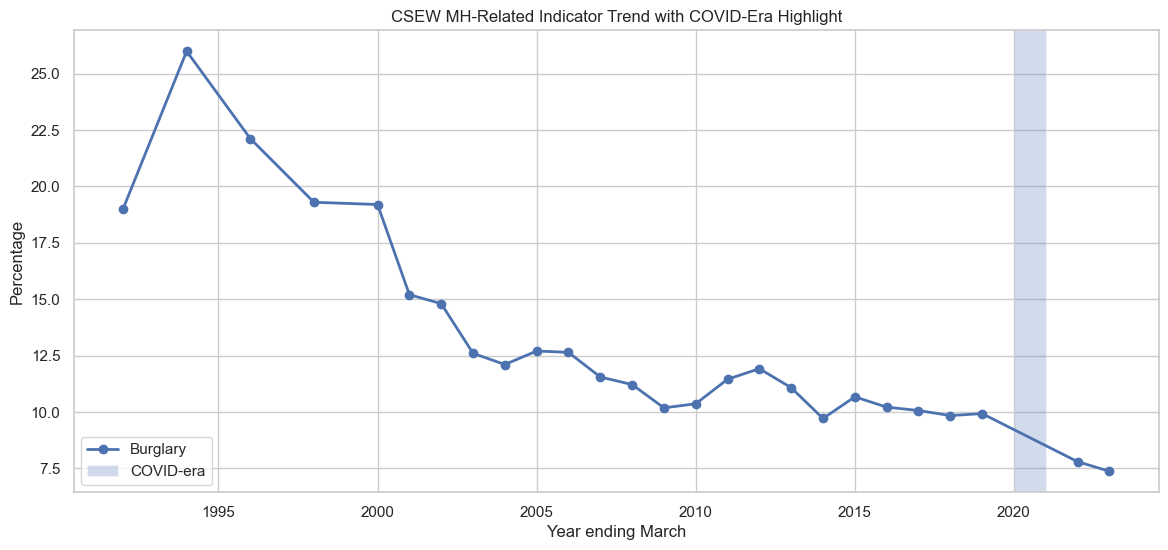

Plot saved successfully.


In [28]:
# Save final COVID-highlight plot

plt.figure(figsize=(14, 6))

plt.plot(
    mh_trend["End_Year"],
    mh_trend["Percentage"],
    marker="o",
    linewidth=2,
    label=selected_indicator
)

plt.axvspan(2020, 2021, alpha=0.25, label="COVID-era")

plt.title("CSEW MH-Related Indicator Trend with COVID-Era Highlight")
plt.xlabel("Year ending March")
plt.ylabel("Percentage")
plt.legend()
plt.grid(True)

plt.savefig("csew_mh_trend_covid_highlight.png", dpi=300, bbox_inches="tight")

plt.show()

print("Plot saved successfully.")

In [30]:
#  First column = indicator name
indicator_col = table_s27.columns[0]


In [31]:
# 3. Convert wide data to long data

trend_long = table_s27.melt(
    id_vars=indicator_col,
    var_name="Year_Period",
    value_name="Percentage"
)

trend_long["Percentage"] = pd.to_numeric(trend_long["Percentage"], errors="coerce")
trend_long = trend_long.dropna(subset=["Percentage"])

In [32]:
# 4. Keep only 2019–2024 columns

required_periods = [
    "Apr 2019 to Mar 2020",
    "Apr 2020 to Mar 2021",
    "Apr 2021 to Mar 2022",
    "Apr 2022 to Mar 2023",
    "Apr 2023 to Mar 2024"
]

trend_2019_2024 = trend_long[
    trend_long["Year_Period"].isin(required_periods)
].copy()

In [33]:
# Create year label
year_map = {
    "Apr 2019 to Mar 2020": "2019-20",
    "Apr 2020 to Mar 2021": "2020-21",
    "Apr 2021 to Mar 2022": "2021-22",
    "Apr 2022 to Mar 2023": "2022-23",
    "Apr 2023 to Mar 2024": "2023-24"
}

trend_2019_2024["Year"] = trend_2019_2024["Year_Period"].map(year_map)

In [35]:
# Select MH-related indicator

selected_indicator = trend_2019_2024[indicator_col].unique()[0]

mh_trend = trend_2019_2024[
    trend_2019_2024[indicator_col] == selected_indicator
].copy()

mh_trend["Year"] = pd.Categorical(
    mh_trend["Year"],
    categories=["2019-20", "2020-21", "2021-22", "2022-23", "2023-24"],
    ordered=True
)

mh_trend = mh_trend.sort_values("Year")

print(mh_trend)

    Crime type           Year_Period  Percentage     Year
92    Burglary  Apr 2019 to Mar 2020    9.922278  2019-20
96    Burglary  Apr 2022 to Mar 2023    7.789778  2022-23
100   Burglary  Apr 2023 to Mar 2024    7.364805  2023-24


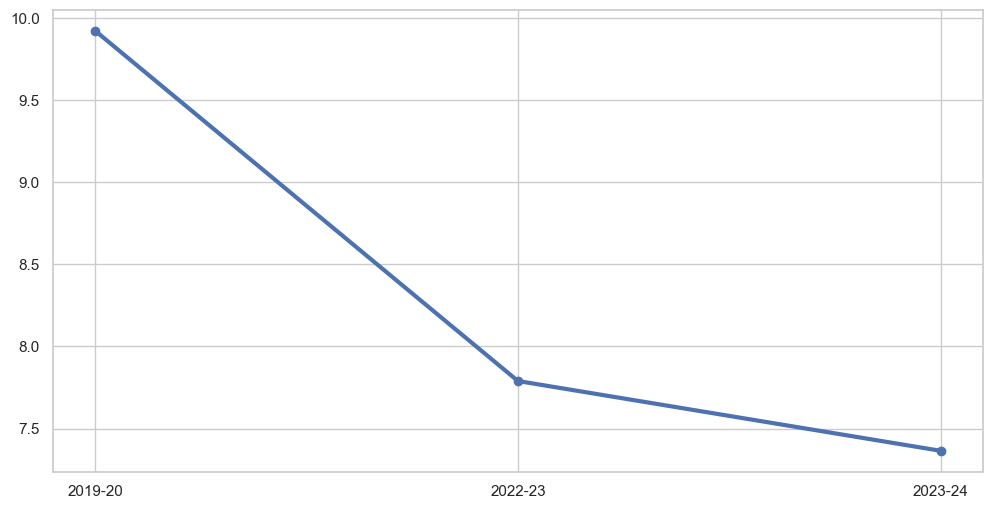

In [36]:
# Plot 2019–2024 MH trend
plt.figure(figsize=(12, 6))

plt.plot(
    mh_trend["Year"],
    mh_trend["Percentage"],
    marker="o",
    linewidth=3,
    label="MH-related indicator"
)

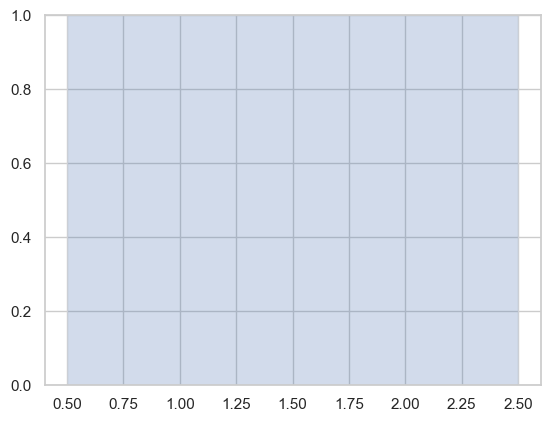

In [37]:
# Highlight COVID era
plt.axvspan(0.5, 2.5, alpha=0.25, label="COVID-era")

In [40]:
print(table_s27.columns.tolist())
print(trend_long["Year_Period"].unique())

['Crime type', 'Jan 1992 to Dec 1992', 'Jan 1994 to Dec 1994', 'Jan 1996 to Dec 1996', 'Jan 1998 to Dec 1998', 'Jan 2000 to Dec 2000', 'Apr 2001 to Mar 2002', 'Apr 2002 to Mar 2003', 'Apr 2003 to Mar 2004', 'Apr 2004 to Mar 2005', 'Apr 2005 to Mar 2006', 'Apr 2006 to Mar 2007', 'Apr 2007 to Mar 2008', 'Apr 2008 to Mar 2009 [note 4]', 'Apr 2009 to Mar 2010', 'Apr 2010 to Mar 2011', 'Apr 2011 to Mar 2012', 'Apr  2012 to Mar 2013', 'Apr 2013 to Mar 2014', 'Apr 2014 to Mar 2015', 'Apr 2015 to Mar 2016', 'Apr 2016 to Mar 2017', 'Apr 2017 to Mar 2018', 'Apr 2018 to Mar 2019', 'Apr 2019 to Mar 2020', 'Apr 2022 to Mar 2023', 'Apr 2023 to Mar 2024', 'Apr 2023 to Mar 2024 compared with Apr 2013 to Mar 2014 Statistically significant difference', 'Apr 2023 to Mar 2024 compared with Apr 2022 to Mar 2023 Statistically significant difference']
['Jan 1992 to Dec 1992' 'Jan 1994 to Dec 1994' 'Jan 1996 to Dec 1996'
 'Jan 1998 to Dec 1998' 'Jan 2000 to Dec 2000' 'Apr 2001 to Mar 2002'
 'Apr 2002 to Mar 2

C:\Users\rajmu\AppData\Local\Temp\ipykernel_20584\2467357870.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


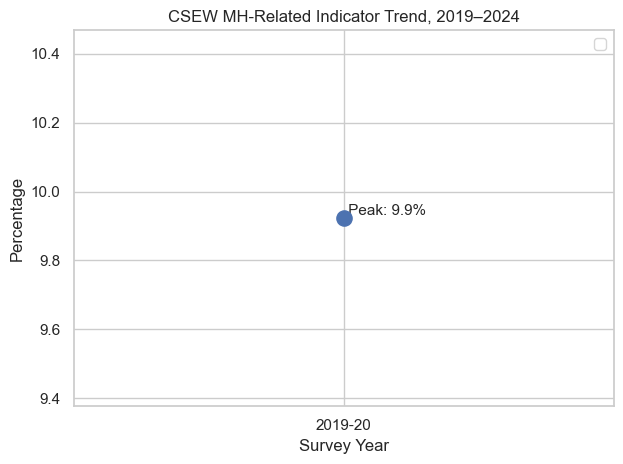

In [41]:
# Peak point
peak = mh_trend.loc[mh_trend["Percentage"].idxmax()]

plt.scatter(
    peak["Year"],
    peak["Percentage"],
    s=120,
    zorder=5
)

plt.text(
    peak["Year"],
    peak["Percentage"],
    f" Peak: {peak['Percentage']:.1f}%",
    fontsize=11,
    ha="left",
    va="bottom"
)

plt.title("CSEW MH-Related Indicator Trend, 2019–2024")
plt.xlabel("Survey Year")
plt.ylabel("Percentage")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()